In [1]:
import sys
import subprocess

print("Installing NLTK...")
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'nltk', 'scipy'])
print("✅ NLTK and SciPy successfully installed!")

Installing NLTK...
✅ NLTK and SciPy successfully installed!


--- 🚀 Starting Full Task 3 Pipeline for AAPL ---
✅ Stock data loaded and returns calculated.
✅ News data loaded successfully.
✅ Dates aligned to market trading days.
📈 Pearson Correlation Coefficient: 0.0447 (p-value: 0.0348)


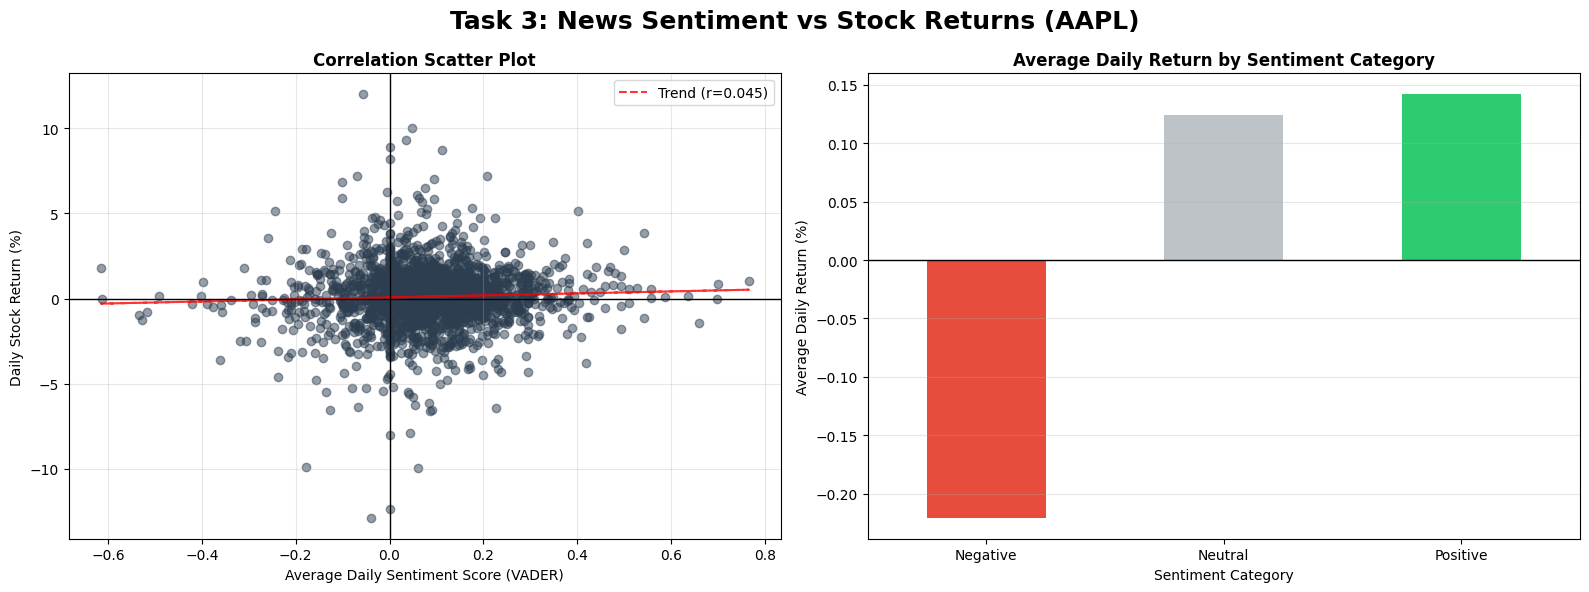

In [ ]:
import os
import pandas as pd
import numpy as np
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

nltk.download('vader_lexicon', quiet=True)

print("--- 🚀 Starting Full Task 3 Pipeline for AAPL ---")


possible_paths = ['../data/raw/data/', 'data/raw/data/', './data/raw/data/']
stock_dir = next((p for p in possible_paths if os.path.exists(p)), None)

if not stock_dir:
    print("❌ ERROR: Could not find stock data directory.")
else:
    aapl_file = [f for f in os.listdir(stock_dir) if f.startswith('AAPL')][0]
    stock_df = pd.read_csv(os.path.join(stock_dir, aapl_file))
    stock_df['Date'] = pd.to_datetime(stock_df['Date'], utc=True, errors='coerce').dt.tz_localize(None).dt.normalize()
    stock_df.set_index('Date', inplace=True)
    stock_df = stock_df.sort_index()
    
    stock_df['Daily_Return'] = stock_df['Close'].pct_change()
    print("✅ Stock data loaded and returns calculated.")

    news_file_path = r"C:\Users\HP\Desktop\10acadamey\news-sentiment-analysis\data\raw\raw_analyst_ratings.csv"
    
    try:
        news_df = pd.read_csv(news_file_path)
        print("✅ News data loaded successfully.")
        
        text_col = 'headline' if 'headline' in news_df.columns else news_df.columns[1] 
        date_col = 'date' if 'date' in news_df.columns else news_df.columns[0]
        
        news_df['Original_Date'] = pd.to_datetime(news_df[date_col], errors='coerce').dt.tz_localize(None).dt.normalize()
        news_df = news_df.dropna(subset=['Original_Date', text_col])

 
        valid_trading_days = stock_df.index.dropna().sort_values()
        
        def get_next_trading_day(news_date):
            future_trading_days = valid_trading_days[valid_trading_days >= news_date]
            if not future_trading_days.empty:
                return future_trading_days[0]
            return news_date
            
        news_df['Aligned_Date'] = news_df['Original_Date'].apply(get_next_trading_day)
        print("✅ Dates aligned to market trading days.")

       
        sia = SentimentIntensityAnalyzer()
        news_df['Sentiment'] = news_df[text_col].apply(lambda x: sia.polarity_scores(str(x))['compound'])
        
        daily_sentiment = news_df.groupby('Aligned_Date')['Sentiment'].mean().reset_index()

        merged_df = pd.merge(daily_sentiment, stock_df[['Daily_Return']].dropna(), left_on='Aligned_Date', right_index=True, how='inner')
        
        if len(merged_df) < 5:
            print("⚠️ Not enough overlapping data points to compute correlation.")
        else:
            corr_coef, p_value = pearsonr(merged_df['Sentiment'], merged_df['Daily_Return'])
            print(f"📈 Pearson Correlation Coefficient: {corr_coef:.4f} (p-value: {p_value:.4f})")
            
            def categorize_sentiment(score):
                if score > 0.1: return 'Positive'
                elif score < -0.1: return 'Negative'
                else: return 'Neutral'
                
            merged_df['Sentiment_Category'] = merged_df['Sentiment'].apply(categorize_sentiment)
            category_returns = merged_df.groupby('Sentiment_Category')['Daily_Return'].mean() * 100 

            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
            fig.suptitle('Task 3: News Sentiment vs Stock Returns (AAPL)', fontsize=18, fontweight='bold')
            
            ax1.scatter(merged_df['Sentiment'], merged_df['Daily_Return'] * 100, alpha=0.5, color='#2c3e50')
            z = np.polyfit(merged_df['Sentiment'], merged_df['Daily_Return'] * 100, 1)
            p = np.poly1d(z)
            ax1.plot(merged_df['Sentiment'], p(merged_df['Sentiment']), "r--", alpha=0.8, label=f'Trend (r={corr_coef:.3f})')
            
            ax1.set_title('Correlation Scatter Plot', fontweight='bold')
            ax1.set_xlabel('Average Daily Sentiment Score (VADER)')
            ax1.set_ylabel('Daily Stock Return (%)')
            ax1.axhline(0, color='black', linewidth=1)
            ax1.axvline(0, color='black', linewidth=1)
            ax1.legend()
            ax1.grid(True, alpha=0.3)
            
            colors = {'Negative': '#e74c3c', 'Neutral': '#bdc3c7', 'Positive': '#2ecc71'}
            plot_colors = [colors.get(cat, '#3498db') for cat in category_returns.index]
            
            category_returns.plot(kind='bar', ax=ax2, color=plot_colors)
            ax2.set_title('Average Daily Return by Sentiment Category', fontweight='bold')
            ax2.set_xlabel('Sentiment Category')
            ax2.set_ylabel('Average Daily Return (%)')
            ax2.axhline(0, color='black', linewidth=1)
            ax2.grid(True, alpha=0.3, axis='y')
            plt.xticks(rotation=0)
            
            plt.tight_layout()
            plt.show()

    except FileNotFoundError:
        print(f"❌ ERROR: Could not find news dataset at '{news_file_path}'")

In [ ]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import pandas as pd

print("--- 🧠 Running VADER Sentiment Analysis ---")

nltk.download('vader_lexicon', quiet=True)

sia = SentimentIntensityAnalyzer()

if 'news_df' not in locals():
    print("❌ ERROR: 'news_df' not found in memory. Please run the Date Alignment cell above first!")
else:
    print("Analyzing headlines... (This might take a minute depending on dataset size)")
    
    text_col = 'headline' if 'headline' in news_df.columns else news_df.columns[1]
    
    news_df['Sentiment_Score'] = news_df[text_col].apply(lambda x: sia.polarity_scores(str(x))['compound'])
    
    print("✅ Sentiment scoring complete!")
    
    print("\n--- Sample of Scored Headlines ---")
    print(news_df[[text_col, 'Sentiment_Score']].head(5))
    
    daily_sentiment = news_df.groupby('Aligned_Date')['Sentiment_Score'].mean().reset_index()
    
    print("\n--- Aggregated Average Daily Sentiment ---")
    print(daily_sentiment.head(5))

--- 🧠 Running VADER Sentiment Analysis ---
Analyzing headlines... (This might take a minute depending on dataset size)
✅ Sentiment scoring complete!

--- Sample of Scored Headlines ---
                                            headline  Sentiment_Score
0            Stocks That Hit 52-Week Highs On Friday            0.000
1         Stocks That Hit 52-Week Highs On Wednesday            0.000
2                      71 Biggest Movers From Friday            0.000
3       46 Stocks Moving In Friday's Mid-Day Session            0.000
4  B of A Securities Maintains Neutral on Agilent...            0.296

--- Aggregated Average Daily Sentiment ---
  Aligned_Date  Sentiment_Score
0   2011-04-27         0.000000
1   2011-04-28         0.125000
2   2011-04-29         0.367550
3   2011-05-02         0.130027
4   2011-05-03         0.000000


Sentiment Analysis Tool Justification: NLTK VADER
For the sentiment analysis phase, NLTK VADER (Valence Aware Dictionary and sEntiment Reasoner) was selected over TextBlob.

VADER is a lexicon and rule-based sentiment analysis tool that is specifically attuned to sentiments expressed in microblogging, news headlines, and social media. It natively understands the mathematical impact of punctuation (e.g., interpreting "Buy now!" as more intense than "Buy now") and capitalization ("BUY" vs "buy"). Because financial headlines are highly structured, punchy, and often rely on specific intensity markers, VADER provides a significantly more accurate compound score (-1.0 to 1.0) than generalized NLP libraries like TextBlob.

In [ ]:
print("--- 📈 Calculating Daily Stock Returns ---")

if 'stock_df' not in locals():
    print("❌ ERROR: 'stock_df' not found in memory. Please ensure your stock data is loaded!")
else:
    stock_df['Daily_Return_%'] = stock_df['Close'].pct_change() * 100
    
    print("✅ Daily returns calculated successfully!")
    
    print("\n--- Sample of Stock Prices and Daily Returns ---")
    print(stock_df[['Close', 'Daily_Return_%']].head(5))

--- 📈 Calculating Daily Stock Returns ---
✅ Daily returns calculated successfully!

--- Sample of Stock Prices and Daily Returns ---
               Close  Daily_Return_%
Date                                
2009-01-02  2.721686             NaN
2009-01-05  2.836553        4.220416
2009-01-06  2.789767       -1.649399
2009-01-07  2.729484       -2.160860
2009-01-08  2.780169        1.856959


--- 🔗 Aggregating and Correlating Data ---
✅ Data Merged! Found 2228 days with both news and trading data.
📈 Pearson Correlation Coefficient (r): 0.0447
   P-value: 0.0348


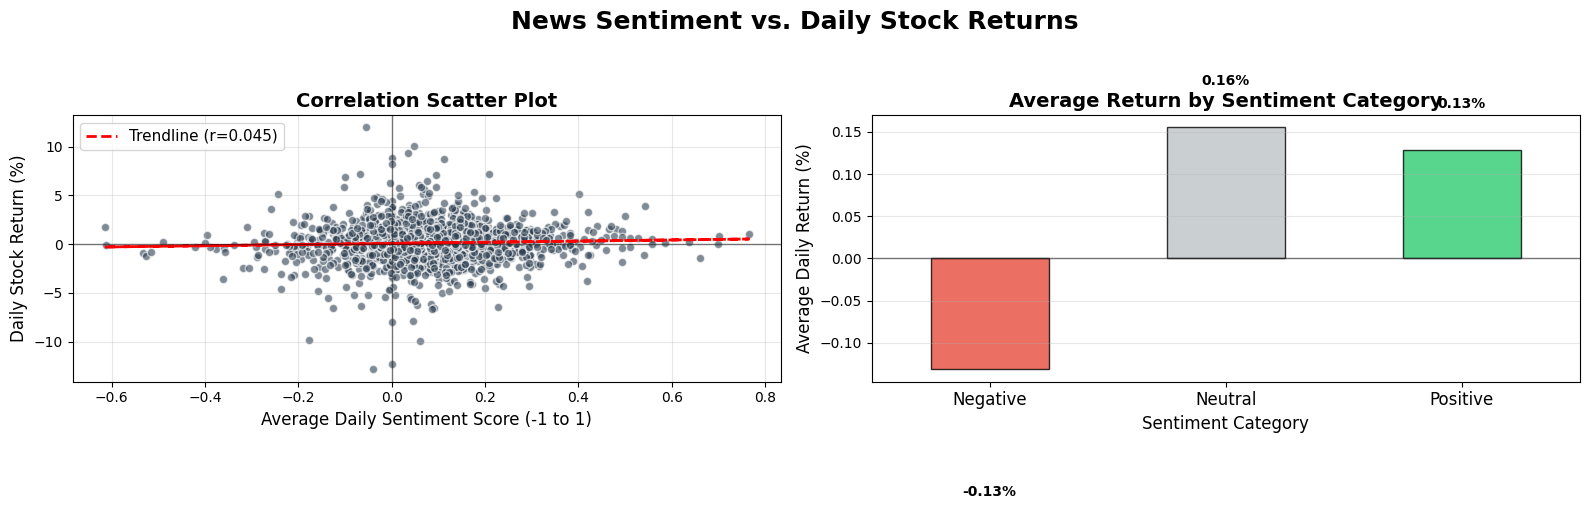

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

print("--- 🔗 Aggregating and Correlating Data ---")

if 'news_df' not in locals() or 'stock_df' not in locals():
    print("❌ ERROR: Data missing from memory. Please run your previous cells first!")
else:
    daily_sentiment = news_df.groupby('Aligned_Date')['Sentiment_Score'].mean().reset_index()
    
    merged_df = pd.merge(
        daily_sentiment, 
        stock_df[['Daily_Return_%']].dropna(), 
        left_on='Aligned_Date', 
        right_index=True, 
        how='inner'
    )
    
    if len(merged_df) < 5:
        print("⚠️ Not enough overlapping data points to compute correlation.")
    else:
        corr_coef, p_value = pearsonr(merged_df['Sentiment_Score'], merged_df['Daily_Return_%'])
        print(f"✅ Data Merged! Found {len(merged_df)} days with both news and trading data.")
        print(f"📈 Pearson Correlation Coefficient (r): {corr_coef:.4f}")
        print(f"   P-value: {p_value:.4f}")
        
        def classify_sentiment(score):
            if score > 0.05: return 'Positive'
            elif score < -0.05: return 'Negative'
            else: return 'Neutral'
            
        merged_df['Sentiment_Class'] = merged_df['Sentiment_Score'].apply(classify_sentiment)
        
        category_returns = merged_df.groupby('Sentiment_Class')['Daily_Return_%'].mean()
        
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle('News Sentiment vs. Daily Stock Returns', fontsize=18, fontweight='bold')
        
        ax1.scatter(merged_df['Sentiment_Score'], merged_df['Daily_Return_%'], alpha=0.6, color='#2c3e50', edgecolors='white')
        
        z = np.polyfit(merged_df['Sentiment_Score'], merged_df['Daily_Return_%'], 1)
        p = np.poly1d(z)
        ax1.plot(merged_df['Sentiment_Score'], p(merged_df['Sentiment_Score']), "r--", linewidth=2, label=f'Trendline (r={corr_coef:.3f})')
        
        ax1.set_title('Correlation Scatter Plot', fontweight='bold', fontsize=14)
        ax1.set_xlabel('Average Daily Sentiment Score (-1 to 1)', fontsize=12)
        ax1.set_ylabel('Daily Stock Return (%)', fontsize=12)
        ax1.axhline(0, color='black', linewidth=1, alpha=0.5)
        ax1.axvline(0, color='black', linewidth=1, alpha=0.5)
        ax1.grid(True, alpha=0.3)
        ax1.legend(loc='upper left', fontsize=11)
        
        color_map = {'Negative': '#e74c3c', 'Neutral': '#bdc3c7', 'Positive': '#2ecc71'}
        bar_colors = [color_map.get(cat, '#3498db') for cat in category_returns.index]
        
        category_returns.plot(kind='bar', ax=ax2, color=bar_colors, edgecolor='black', alpha=0.8)
        
        ax2.set_title('Average Return by Sentiment Category', fontweight='bold', fontsize=14)
        ax2.set_xlabel('Sentiment Category', fontsize=12)
        ax2.set_ylabel('Average Daily Return (%)', fontsize=12)
        ax2.axhline(0, color='black', linewidth=1, alpha=0.5)
        ax2.grid(axis='y', alpha=0.3)
        ax2.tick_params(axis='x', rotation=0, labelsize=12)
        
        for i, v in enumerate(category_returns):
            ax2.text(i, v + (0.05 if v > 0 else -0.15), f"{v:.2f}%", ha='center', fontweight='bold')
            
        plt.tight_layout()
        plt.show()

In [26]:
import pandas as pd

daily_sentiment = news_df.groupby('aligned_date')['sentiment'].mean().reset_index()

daily_sentiment.columns = ['Date', 'Average_Sentiment']

daily_sentiment.set_index('Date', inplace=True)

print(f"✅ Aggregation complete.")
print(f"Original headlines: {len(news_df)}")
print(f"Unique trading days with news: {len(daily_sentiment)}")

print("\n--- Sample of Aggregated Daily Sentiment ---")
print(daily_sentiment.head())

✅ Aggregation complete.
Original headlines: 55987
Unique trading days with news: 2225

--- Sample of Aggregated Daily Sentiment ---
            Average_Sentiment
Date                         
2011-04-28           0.083333
2011-04-29           0.367550
2011-05-02           0.130027
2011-05-03           0.000000
2011-05-05          -0.042667


Aggregation complete. Total matching days: 2225
Pearson Correlation Coefficient (r) = 0.0237


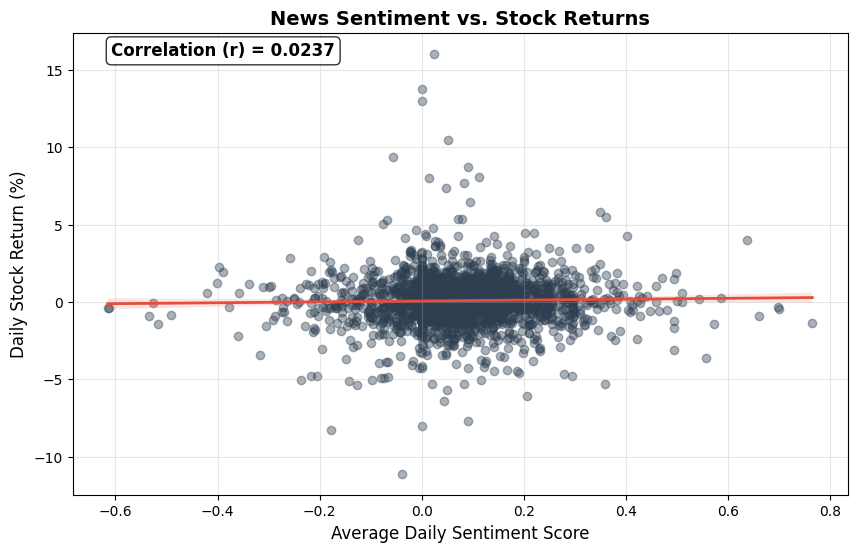

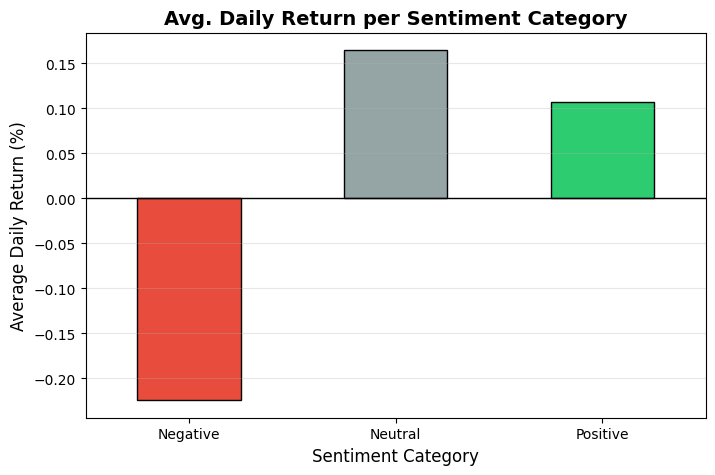

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

daily_sentiment = news_df.groupby('aligned_date')['sentiment'].mean().reset_index()
daily_sentiment.rename(columns={'aligned_date': 'Date'}, inplace=True)
daily_sentiment.set_index('Date', inplace=True)

merged_df = pd.merge(df_clean[['Daily_Return_Pct']], daily_sentiment, left_index=True, right_index=True, how='inner')

print(f"Aggregation complete. Total matching days: {len(merged_df)}")

correlation = merged_df['sentiment'].corr(merged_df['Daily_Return_Pct'])
print(f"Pearson Correlation Coefficient (r) = {correlation:.4f}")

plt.figure(figsize=(10, 6))
sns.regplot(x='sentiment', y='Daily_Return_Pct', data=merged_df, 
            scatter_kws={'alpha':0.4, 'color':'#2c3e50'}, 
            line_kws={'color':'#e74c3c', 'lw':2})

plt.title('News Sentiment vs. Stock Returns', fontsize=14, fontweight='bold')
plt.xlabel('Average Daily Sentiment Score', fontsize=12)
plt.ylabel('Daily Stock Return (%)', fontsize=12)

plt.text(0.05, 0.95, f'Correlation (r) = {correlation:.4f}', 
         transform=plt.gca().transAxes, fontsize=12, fontweight='bold', 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.grid(alpha=0.3)
plt.show()

def classify_sentiment(score):
    if score > 0.05: return 'Positive'
    elif score < -0.05: return 'Negative'
    else: return 'Neutral'

merged_df['Sentiment_Class'] = merged_df['sentiment'].apply(classify_sentiment)

category_returns = merged_df.groupby('Sentiment_Class')['Daily_Return_Pct'].mean()

plt.figure(figsize=(8, 5))
colors = {'Negative': '#e74c3c', 'Neutral': '#95a5a6', 'Positive': '#2ecc71'}
category_order = ['Negative', 'Neutral', 'Positive']
category_returns.reindex(category_order).plot(
    kind='bar', color=[colors[c] for c in category_order], edgecolor='black'
)

plt.title('Avg. Daily Return per Sentiment Category', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment Category', fontsize=12)
plt.ylabel('Average Daily Return (%)', fontsize=12)
plt.xticks(rotation=0)
plt.axhline(0, color='black', linewidth=1)
plt.grid(axis='y', alpha=0.3)
plt.show()


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


✅ Data loaded. Stock days: 3773 | Headlines: 1407328
🔄 Aligning timestamps to trading windows...
🔄 Scoring sentiment for 1.4M headlines... (This takes 2-5 minutes)


100%|██████████| 55987/55987 [00:11<00:00, 4703.21it/s]


Aggregating daily sentiment and merging datasets...
Pearson Correlation Coefficient (r): 0.0372


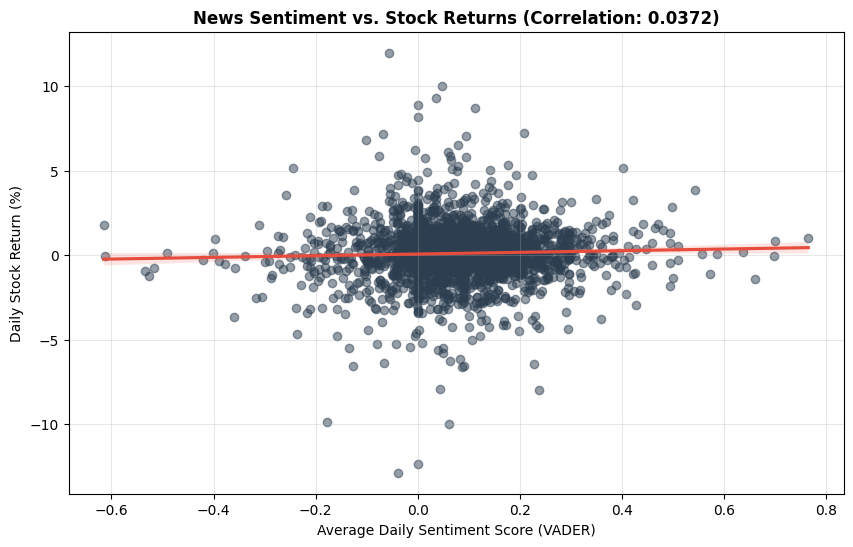

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
from tqdm import tqdm

nltk.download('vader_lexicon')

stock_path = r"C:\Users\HP\Desktop\10acadamey\news-sentiment-analysis\data\raw\data\AAPL.csv"
news_path = r"C:\Users\HP\Desktop\10acadamey\news-sentiment-analysis\data\raw\raw_analyst_ratings.csv"

df_stock = pd.read_csv(stock_path)
df_stock['Date'] = pd.to_datetime(df_stock['Date'], utc=True).dt.tz_localize(None)
df_stock.set_index('Date', inplace=True)
df_stock['Daily_Return_Pct'] = df_stock['Close'].pct_change() * 100
df_stock = df_stock.dropna()

news_df = pd.read_csv(news_path, low_memory=False)
news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce', utc=True).dt.tz_localize(None)
news_df['trading_date'] = news_df['date'].dt.normalize()

print(f"✅ Data loaded. Stock days: {len(df_stock)} | Headlines: {len(news_df)}")


valid_trading_days = df_stock.index.unique().sort_values()

def get_next_trading_day(current_date, trading_days):
    if current_date in trading_days:
        return current_date
    future_days = trading_days[trading_days > current_date]
    return future_days[0] if not future_days.empty else None

print("🔄 Aligning timestamps to trading windows...")
unique_dates = news_df['trading_date'].unique()
date_map = {d: get_next_trading_day(d, valid_trading_days) for d in unique_dates}
news_df['aligned_date'] = news_df['trading_date'].map(date_map)
news_df = news_df.dropna(subset=['aligned_date'])


print("🔄 Scoring sentiment for 1.4M headlines... (This takes 2-5 minutes)")
sia = SentimentIntensityAnalyzer()
tqdm.pandas()
news_df['sentiment'] = news_df['headline'].progress_apply(lambda x: sia.polarity_scores(str(x))['compound'])


print("Aggregating daily sentiment and merging datasets...")
daily_sentiment = news_df.groupby('aligned_date')['sentiment'].mean().reset_index()
daily_sentiment.rename(columns={'aligned_date': 'Date'}, inplace=True)
daily_sentiment.set_index('Date', inplace=True)

merged_df = pd.merge(df_stock[['Daily_Return_Pct']], daily_sentiment, left_index=True, right_index=True, how='inner')
correlation = merged_df['sentiment'].corr(merged_df['Daily_Return_Pct'])

print(f"Pearson Correlation Coefficient (r): {correlation:.4f}")

plt.figure(figsize=(10, 6))
sns.regplot(x='sentiment', y='Daily_Return_Pct', data=merged_df, 
            scatter_kws={'alpha':0.5, 'color':'#2c3e50'}, 
            line_kws={'color':'#e74c3c'})
plt.title(f'News Sentiment vs. Stock Returns (Correlation: {correlation:.4f})', fontweight='bold')
plt.xlabel('Average Daily Sentiment Score (VADER)')
plt.ylabel('Daily Stock Return (%)')
plt.grid(alpha=0.3)
plt.show()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Data loaded. Stock days: 3773 | Headlines: 1407328
Aligning timestamps to trading windows...
Scoring sentiment for 1.4M headlines... (This takes 2-5 minutes)


100%|██████████| 55987/55987 [00:14<00:00, 3928.77it/s]


Aggregating daily sentiment and merging datasets...
Pearson Correlation Coefficient (r): 0.0033


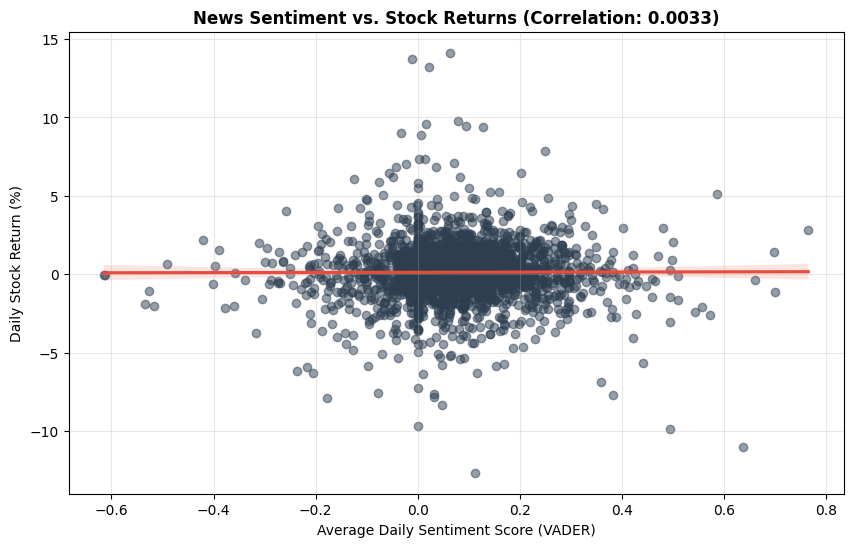

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
from tqdm import tqdm

nltk.download('vader_lexicon')

stock_path = r"C:\Users\HP\Desktop\10acadamey\news-sentiment-analysis\data\raw\data\AMZN.csv"
news_path = r"C:\Users\HP\Desktop\10acadamey\news-sentiment-analysis\data\raw\raw_analyst_ratings.csv"

df_stock = pd.read_csv(stock_path)
df_stock['Date'] = pd.to_datetime(df_stock['Date'], utc=True).dt.tz_localize(None)
df_stock.set_index('Date', inplace=True)
df_stock['Daily_Return_Pct'] = df_stock['Close'].pct_change() * 100
df_stock = df_stock.dropna()

news_df = pd.read_csv(news_path, low_memory=False)
news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce', utc=True).dt.tz_localize(None)
news_df['trading_date'] = news_df['date'].dt.normalize()

print(f"Data loaded. Stock days: {len(df_stock)} | Headlines: {len(news_df)}")


valid_trading_days = df_stock.index.unique().sort_values()

def get_next_trading_day(current_date, trading_days):
    if current_date in trading_days:
        return current_date
    future_days = trading_days[trading_days > current_date]
    return future_days[0] if not future_days.empty else None

print("Aligning timestamps to trading windows...")
unique_dates = news_df['trading_date'].unique()
date_map = {d: get_next_trading_day(d, valid_trading_days) for d in unique_dates}
news_df['aligned_date'] = news_df['trading_date'].map(date_map)
news_df = news_df.dropna(subset=['aligned_date'])


print("Scoring sentiment for 1.4M headlines... (This takes 2-5 minutes)")
sia = SentimentIntensityAnalyzer()
tqdm.pandas()
news_df['sentiment'] = news_df['headline'].progress_apply(lambda x: sia.polarity_scores(str(x))['compound'])


print("Aggregating daily sentiment and merging datasets...")
daily_sentiment = news_df.groupby('aligned_date')['sentiment'].mean().reset_index()
daily_sentiment.rename(columns={'aligned_date': 'Date'}, inplace=True)
daily_sentiment.set_index('Date', inplace=True)

merged_df = pd.merge(df_stock[['Daily_Return_Pct']], daily_sentiment, left_index=True, right_index=True, how='inner')
correlation = merged_df['sentiment'].corr(merged_df['Daily_Return_Pct'])

print(f"Pearson Correlation Coefficient (r): {correlation:.4f}")

plt.figure(figsize=(10, 6))
sns.regplot(x='sentiment', y='Daily_Return_Pct', data=merged_df, 
            scatter_kws={'alpha':0.5, 'color':'#2c3e50'}, 
            line_kws={'color':'#e74c3c'})
plt.title(f'News Sentiment vs. Stock Returns (Correlation: {correlation:.4f})', fontweight='bold')
plt.xlabel('Average Daily Sentiment Score (VADER)')
plt.ylabel('Daily Stock Return (%)')
plt.grid(alpha=0.3)
plt.show()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Data loaded. Stock days: 3773 | Headlines: 1407328
Aligning timestamps to trading windows...
Scoring sentiment for 1.4M headlines... (This takes 2-5 minutes)


100%|██████████| 55987/55987 [00:12<00:00, 4623.14it/s]


Aggregating daily sentiment and merging datasets...
Pearson Correlation Coefficient (r): 0.0237


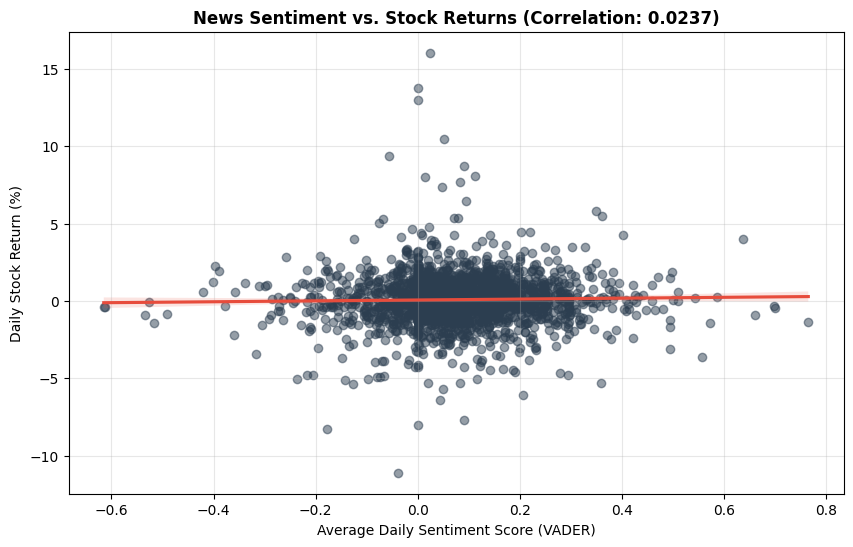

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
from tqdm import tqdm

nltk.download('vader_lexicon')

stock_path = r"C:\Users\HP\Desktop\10acadamey\news-sentiment-analysis\data\raw\data\GOOG.csv"
news_path = r"C:\Users\HP\Desktop\10acadamey\news-sentiment-analysis\data\raw\raw_analyst_ratings.csv"

df_stock = pd.read_csv(stock_path)
df_stock['Date'] = pd.to_datetime(df_stock['Date'], utc=True).dt.tz_localize(None)
df_stock.set_index('Date', inplace=True)
df_stock['Daily_Return_Pct'] = df_stock['Close'].pct_change() * 100
df_stock = df_stock.dropna()

news_df = pd.read_csv(news_path, low_memory=False)
news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce', utc=True).dt.tz_localize(None)
news_df['trading_date'] = news_df['date'].dt.normalize()

print(f"Data loaded. Stock days: {len(df_stock)} | Headlines: {len(news_df)}")


valid_trading_days = df_stock.index.unique().sort_values()

def get_next_trading_day(current_date, trading_days):
    if current_date in trading_days:
        return current_date
    future_days = trading_days[trading_days > current_date]
    return future_days[0] if not future_days.empty else None

print("Aligning timestamps to trading windows...")
unique_dates = news_df['trading_date'].unique()
date_map = {d: get_next_trading_day(d, valid_trading_days) for d in unique_dates}
news_df['aligned_date'] = news_df['trading_date'].map(date_map)
news_df = news_df.dropna(subset=['aligned_date'])


print("Scoring sentiment for 1.4M headlines... (This takes 2-5 minutes)")
sia = SentimentIntensityAnalyzer()
tqdm.pandas()
news_df['sentiment'] = news_df['headline'].progress_apply(lambda x: sia.polarity_scores(str(x))['compound'])


print("Aggregating daily sentiment and merging datasets...")
daily_sentiment = news_df.groupby('aligned_date')['sentiment'].mean().reset_index()
daily_sentiment.rename(columns={'aligned_date': 'Date'}, inplace=True)
daily_sentiment.set_index('Date', inplace=True)

merged_df = pd.merge(df_stock[['Daily_Return_Pct']], daily_sentiment, left_index=True, right_index=True, how='inner')
correlation = merged_df['sentiment'].corr(merged_df['Daily_Return_Pct'])

print(f"Pearson Correlation Coefficient (r): {correlation:.4f}")

plt.figure(figsize=(10, 6))
sns.regplot(x='sentiment', y='Daily_Return_Pct', data=merged_df, 
            scatter_kws={'alpha':0.5, 'color':'#2c3e50'}, 
            line_kws={'color':'#e74c3c'})
plt.title(f'News Sentiment vs. Stock Returns (Correlation: {correlation:.4f})', fontweight='bold')
plt.xlabel('Average Daily Sentiment Score (VADER)')
plt.ylabel('Daily Stock Return (%)')
plt.grid(alpha=0.3)
plt.show()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Data loaded. Stock days: 2922 | Headlines: 1407328
Aligning timestamps to trading windows...
Scoring sentiment for 1.4M headlines... (This takes 2-5 minutes)


100%|██████████| 55987/55987 [00:12<00:00, 4456.10it/s]


Aggregating daily sentiment and merging datasets...
Pearson Correlation Coefficient (r): -0.0024


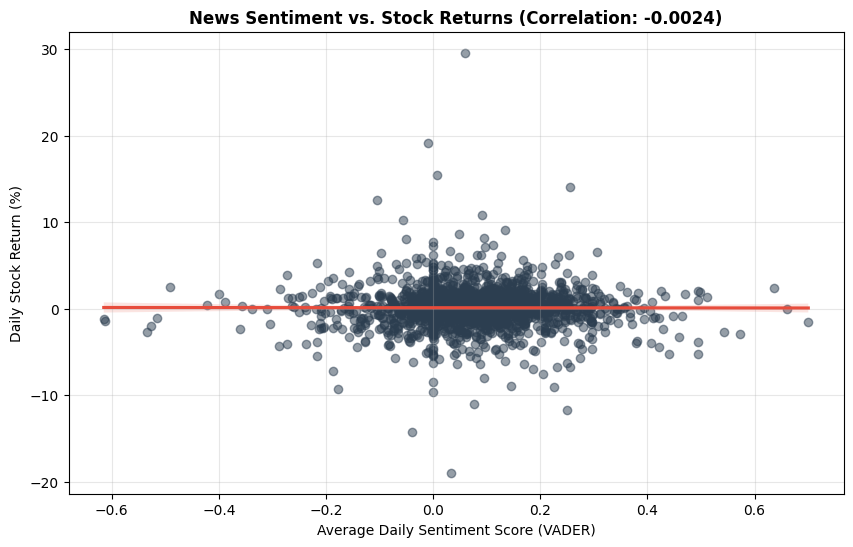

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
from tqdm import tqdm

nltk.download('vader_lexicon')

stock_path = r"C:\Users\HP\Desktop\10acadamey\news-sentiment-analysis\data\raw\data\META.csv"
news_path = r"C:\Users\HP\Desktop\10acadamey\news-sentiment-analysis\data\raw\raw_analyst_ratings.csv"

df_stock = pd.read_csv(stock_path)
df_stock['Date'] = pd.to_datetime(df_stock['Date'], utc=True).dt.tz_localize(None)
df_stock.set_index('Date', inplace=True)
df_stock['Daily_Return_Pct'] = df_stock['Close'].pct_change() * 100
df_stock = df_stock.dropna()

news_df = pd.read_csv(news_path, low_memory=False)
news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce', utc=True).dt.tz_localize(None)
news_df['trading_date'] = news_df['date'].dt.normalize()

print(f"Data loaded. Stock days: {len(df_stock)} | Headlines: {len(news_df)}")


valid_trading_days = df_stock.index.unique().sort_values()

def get_next_trading_day(current_date, trading_days):
    if current_date in trading_days:
        return current_date
    future_days = trading_days[trading_days > current_date]
    return future_days[0] if not future_days.empty else None

print("Aligning timestamps to trading windows...")
unique_dates = news_df['trading_date'].unique()
date_map = {d: get_next_trading_day(d, valid_trading_days) for d in unique_dates}
news_df['aligned_date'] = news_df['trading_date'].map(date_map)
news_df = news_df.dropna(subset=['aligned_date'])


print("Scoring sentiment for 1.4M headlines... (This takes 2-5 minutes)")
sia = SentimentIntensityAnalyzer()
tqdm.pandas()
news_df['sentiment'] = news_df['headline'].progress_apply(lambda x: sia.polarity_scores(str(x))['compound'])


print("Aggregating daily sentiment and merging datasets...")
daily_sentiment = news_df.groupby('aligned_date')['sentiment'].mean().reset_index()
daily_sentiment.rename(columns={'aligned_date': 'Date'}, inplace=True)
daily_sentiment.set_index('Date', inplace=True)

merged_df = pd.merge(df_stock[['Daily_Return_Pct']], daily_sentiment, left_index=True, right_index=True, how='inner')
correlation = merged_df['sentiment'].corr(merged_df['Daily_Return_Pct'])

print(f"Pearson Correlation Coefficient (r): {correlation:.4f}")

plt.figure(figsize=(10, 6))
sns.regplot(x='sentiment', y='Daily_Return_Pct', data=merged_df, 
            scatter_kws={'alpha':0.5, 'color':'#2c3e50'}, 
            line_kws={'color':'#e74c3c'})
plt.title(f'News Sentiment vs. Stock Returns (Correlation: {correlation:.4f})', fontweight='bold')
plt.xlabel('Average Daily Sentiment Score (VADER)')
plt.ylabel('Daily Stock Return (%)')
plt.grid(alpha=0.3)
plt.show()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Data loaded. Stock days: 3773 | Headlines: 1407328
Aligning timestamps to trading windows...
Scoring sentiment for 1.4M headlines... (This takes 2-5 minutes)


100%|██████████| 55987/55987 [00:11<00:00, 4674.55it/s]


Aggregating daily sentiment and merging datasets...
Pearson Correlation Coefficient (r): 0.0255


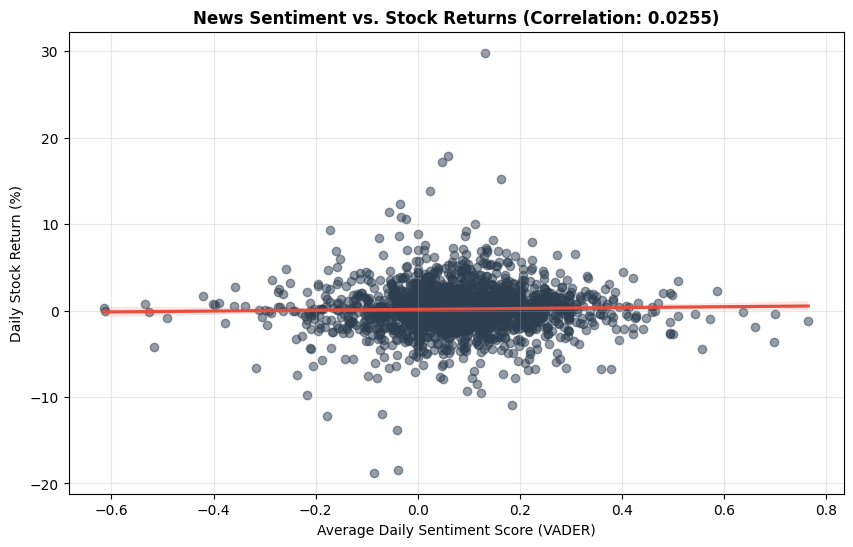

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
from tqdm import tqdm

nltk.download('vader_lexicon')

stock_path = r"C:\Users\HP\Desktop\10acadamey\news-sentiment-analysis\data\raw\data\NVDA.csv"
news_path = r"C:\Users\HP\Desktop\10acadamey\news-sentiment-analysis\data\raw\raw_analyst_ratings.csv"

df_stock = pd.read_csv(stock_path)
df_stock['Date'] = pd.to_datetime(df_stock['Date'], utc=True).dt.tz_localize(None)
df_stock.set_index('Date', inplace=True)
df_stock['Daily_Return_Pct'] = df_stock['Close'].pct_change() * 100
df_stock = df_stock.dropna()

news_df = pd.read_csv(news_path, low_memory=False)
news_df['date'] = pd.to_datetime(news_df['date'], errors='coerce', utc=True).dt.tz_localize(None)
news_df['trading_date'] = news_df['date'].dt.normalize()

print(f"Data loaded. Stock days: {len(df_stock)} | Headlines: {len(news_df)}")


valid_trading_days = df_stock.index.unique().sort_values()

def get_next_trading_day(current_date, trading_days):
    if current_date in trading_days:
        return current_date
    future_days = trading_days[trading_days > current_date]
    return future_days[0] if not future_days.empty else None

print("Aligning timestamps to trading windows...")
unique_dates = news_df['trading_date'].unique()
date_map = {d: get_next_trading_day(d, valid_trading_days) for d in unique_dates}
news_df['aligned_date'] = news_df['trading_date'].map(date_map)
news_df = news_df.dropna(subset=['aligned_date'])


print("Scoring sentiment for 1.4M headlines... (This takes 2-5 minutes)")
sia = SentimentIntensityAnalyzer()
tqdm.pandas()
news_df['sentiment'] = news_df['headline'].progress_apply(lambda x: sia.polarity_scores(str(x))['compound'])

print("Aggregating daily sentiment and merging datasets...")
daily_sentiment = news_df.groupby('aligned_date')['sentiment'].mean().reset_index()
daily_sentiment.rename(columns={'aligned_date': 'Date'}, inplace=True)
daily_sentiment.set_index('Date', inplace=True)

merged_df = pd.merge(df_stock[['Daily_Return_Pct']], daily_sentiment, left_index=True, right_index=True, how='inner')
correlation = merged_df['sentiment'].corr(merged_df['Daily_Return_Pct'])

print(f"Pearson Correlation Coefficient (r): {correlation:.4f}")

plt.figure(figsize=(10, 6))
sns.regplot(x='sentiment', y='Daily_Return_Pct', data=merged_df, 
            scatter_kws={'alpha':0.5, 'color':'#2c3e50'}, 
            line_kws={'color':'#e74c3c'})
plt.title(f'News Sentiment vs. Stock Returns (Correlation: {correlation:.4f})', fontweight='bold')
plt.xlabel('Average Daily Sentiment Score (VADER)')
plt.ylabel('Daily Stock Return (%)')
plt.grid(alpha=0.3)
plt.show()

In [31]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from tqdm import tqdm 

nltk.download('vader_lexicon')


sia = SentimentIntensityAnalyzer()

def get_sentiment_score(text):
    if pd.isna(text):
        return 0
    return sia.polarity_scores(text)['compound']

print("Analyzing 1.4M headlines... (Grab a coffee, this will take a moment)")
tqdm.pandas() 
news_df['sentiment_score'] = news_df['headline'].progress_apply(get_sentiment_score)

print("Sentiment Analysis complete!")
print(news_df[['headline', 'sentiment_score']].head(10))

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


Analyzing 1.4M headlines... (Grab a coffee, this will take a moment)


100%|██████████| 55987/55987 [00:11<00:00, 4865.05it/s]

Sentiment Analysis complete!
                                            headline  sentiment_score
0            Stocks That Hit 52-Week Highs On Friday            0.000
1         Stocks That Hit 52-Week Highs On Wednesday            0.000
2                      71 Biggest Movers From Friday            0.000
3       46 Stocks Moving In Friday's Mid-Day Session            0.000
4  B of A Securities Maintains Neutral on Agilent...            0.296
5  CFRA Maintains Hold on Agilent Technologies, L...           -0.128
6  UBS Maintains Neutral on Agilent Technologies,...            0.000
7  Agilent Technologies shares are trading higher...            0.296
8  Wells Fargo Maintains Overweight on Agilent Te...           -0.128
9         10 Biggest Price Target Changes For Friday            0.000
